# 09 Model Comparison

Compare saved metrics from trained model notebooks.


## 1. Imports and paths


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

model_root = PROJECT_ROOT / "artifacts" / "models"
excluded_models = {"gru", "cnn_gru"}
print("Project root:", PROJECT_ROOT)
model_root


Project root: C:\Users\User\Documents\deep-learning\deep-learning


WindowsPath('C:/Users/User/Documents/deep-learning/deep-learning/artifacts/models')

## 2. Load saved results


In [2]:
metric_rows = []
subject_rows = []
prediction_rows = []

for model_dir in sorted(model_root.iterdir()):
    if not model_dir.is_dir() or model_dir.name in excluded_models:
        continue
    metrics_path = model_dir / "test_metrics.json"
    validation_path = model_dir / "validation_metrics.json"
    config_path = model_dir / "model_config.json"
    summary_path = model_dir / "training_summary.json"
    if not metrics_path.exists():
        continue

    with metrics_path.open("r", encoding="utf-8") as handle:
        test_metrics = json.load(handle)
    validation_metrics = {}
    if validation_path.exists():
        with validation_path.open("r", encoding="utf-8") as handle:
            validation_metrics = json.load(handle)
    config = {}
    if config_path.exists():
        with config_path.open("r", encoding="utf-8") as handle:
            config = json.load(handle)
    training_summary = {}
    if summary_path.exists():
        with summary_path.open("r", encoding="utf-8") as handle:
            training_summary = json.load(handle)

    metric_rows.append(
        {
            "model": model_dir.name,
            "validation_macro_f1": validation_metrics.get("macro_f1"),
            "test_macro_f1": test_metrics.get("macro_f1"),
            "weighted_f1": test_metrics.get("weighted_f1"),
            "stress_precision": test_metrics.get("stress_precision"),
            "stress_recall": test_metrics.get("stress_recall"),
            "roc_auc": test_metrics.get("roc_auc"),
            "average_precision": test_metrics.get("average_precision"),
            "parameter_count": config.get("parameter_count"),
            "selected_imbalance_method": config.get("selected_imbalance_method") or training_summary.get("selected_imbalance_method"),
            "best_epoch": config.get("best_validation_epoch") or training_summary.get("best_epoch"),
            "epochs_trained": training_summary.get("epochs_trained"),
            "training_time_seconds": training_summary.get("training_time_seconds"),
            "inference_time_seconds": training_summary.get("inference_time_seconds"),
        }
    )

    per_subject_path = model_dir / "per_subject_metrics.csv"
    if per_subject_path.exists():
        frame = pd.read_csv(per_subject_path)
        frame.insert(0, "model", model_dir.name)
        subject_rows.append(frame)

    prediction_path = model_dir / "test_predictions.csv"
    if prediction_path.exists():
        frame = pd.read_csv(prediction_path)
        frame.insert(0, "model", model_dir.name)
        prediction_rows.append(frame)

comparison = pd.DataFrame(metric_rows).sort_values("validation_macro_f1", ascending=False, na_position="last")
per_subject_comparison = pd.concat(subject_rows, ignore_index=True) if subject_rows else pd.DataFrame()
prediction_comparison = pd.concat(prediction_rows, ignore_index=True) if prediction_rows else pd.DataFrame()
comparison


results_dir = PROJECT_ROOT / "artifacts" / "results"
results_dir.mkdir(parents=True, exist_ok=True)
if not comparison.empty:
    comparison.to_csv(results_dir / "all_model_metrics.csv", index=False)
    comparison.to_json(results_dir / "all_model_metrics.json", orient="records", indent=2)


## 3. Summary charts


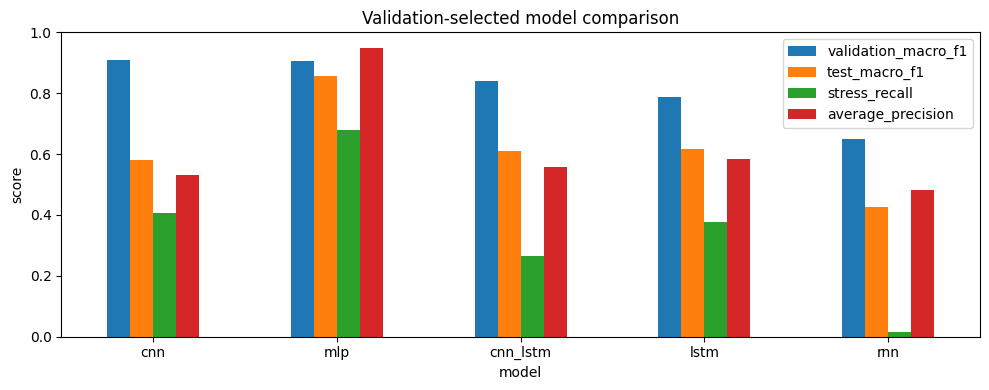

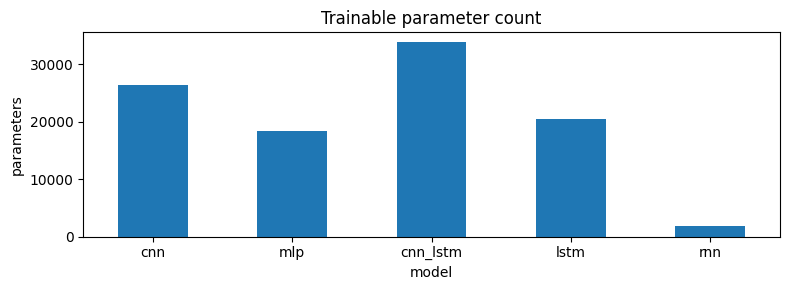

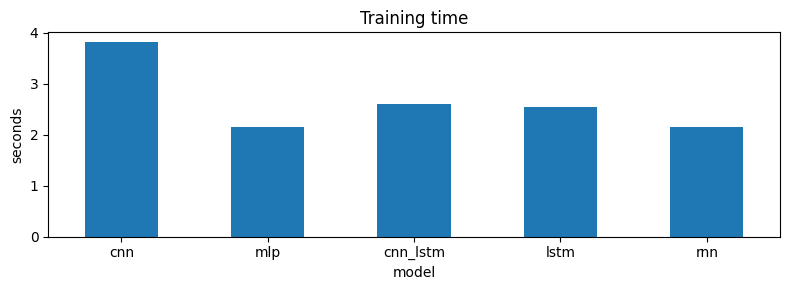

In [3]:
if not comparison.empty:
    score_columns = ["validation_macro_f1", "test_macro_f1", "stress_recall", "average_precision"]
    axes = comparison.set_index("model")[score_columns].plot(
        kind="bar",
        figsize=(10, 4),
        ylim=(0, 1),
    )
    axes.set_ylabel("score")
    axes.set_title("Validation-selected model comparison")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    for column, title, ylabel in [
        ("parameter_count", "Trainable parameter count", "parameters"),
        ("training_time_seconds", "Training time", "seconds"),
    ]:
        if column in comparison and comparison[column].notna().any():
            ax = comparison.set_index("model")[column].plot(kind="bar", figsize=(8, 3))
            ax.set_title(title)
            ax.set_ylabel(ylabel)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()


## 4. Per-subject comparison


model,cnn,cnn_lstm,lstm,mlp,rnn
subject_id,,,,,
S11,0.799246,0.819646,0.838202,0.983422,0.456701
S14,0.257732,0.389831,0.418702,0.912088,0.409836
S2,0.668269,0.513323,0.407725,0.613074,0.412766


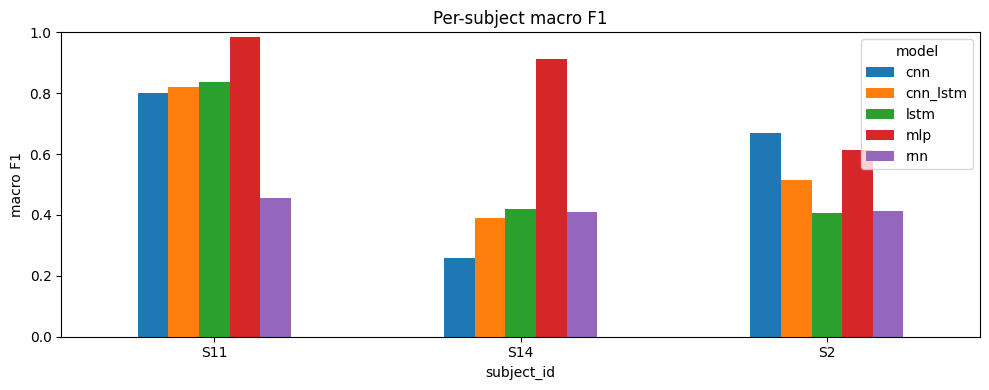

In [4]:
if not per_subject_comparison.empty:
    subject_pivot = per_subject_comparison.pivot_table(
        index="subject_id",
        columns="model",
        values="macro_f1",
    )
    display(subject_pivot)
    subject_pivot.plot(kind="bar", figsize=(10, 4), ylim=(0, 1))
    plt.ylabel("macro F1")
    plt.title("Per-subject macro F1")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 5. Select best model


In [5]:
if comparison.empty:
    print("No trained model artifacts found yet.")
else:
    selected_model = comparison.sort_values("validation_macro_f1", ascending=False, na_position="last").iloc[0]
    highest_observed_test = comparison.sort_values("test_macro_f1", ascending=False, na_position="last").iloc[0]
    print(
        f"Validation-selected deployment candidate: {selected_model['model']} "
        f"(validation macro-F1={selected_model['validation_macro_f1']:.3f}, "
        f"test macro-F1={selected_model['test_macro_f1']:.3f})"
    )
    print(
        f"Highest observed test macro-F1: {highest_observed_test['model']} "
        f"({highest_observed_test['test_macro_f1']:.3f})"
    )
    results_dir = PROJECT_ROOT / "artifacts" / "results"
    results_dir.mkdir(parents=True, exist_ok=True)
    selected_model.to_json(results_dir / "best_model.json", indent=2)
    display(comparison)


Validation-selected deployment candidate: cnn (validation macro-F1=0.909, test macro-F1=0.581)
Highest observed test macro-F1: mlp (0.856)


,model,validation_macro_f1,test_macro_f1,weighted_f1,stress_precision,stress_recall,roc_auc,average_precision,parameter_count,selected_imbalance_method,best_epoch,epochs_trained,training_time_seconds,inference_time_seconds
0,cnn,0.909282,0.581160,0.649037,0.416000,0.406250,0.651190,0.530508,26465,class_weight,2,12,3.813858,0.038652
3,mlp,0.906061,0.856423,0.883995,0.935484,0.679688,0.977061,0.946865,18433,no_correction,11,21,2.150120,0.026060
1,cnn_lstm,0.838518,0.611350,0.702004,0.693878,0.265625,0.710466,0.558133,33857,class_weight,3,13,2.604137,0.024144
2,lstm,0.786946,0.616216,0.689557,0.510638,0.375000,0.696151,0.584098,20545,class_weight,3,13,2.542731,0.031696
4,rnn,0.648350,0.427195,0.585487,0.666667,0.015625,0.612626,0.481694,1825,no_correction,2,12,2.144583,0.023246


## Validation vs Test Interpretation

The CNN is selected because model selection is based on validation macro F1, and it has the highest validation score in this run. The MLP has slightly lower validation macro F1 but much stronger held-out test macro F1. This is plausible because the validation split contains only two subjects, so it can favor temporal patterns that match those subjects but do not transfer as well to the three test subjects. The MLP uses aggregated statistical features and additional duplicate, constant, and correlation filtering, which may reduce subject-specific sequence noise and improve test generalization. For reporting, the validation-selected CNN should remain the protocol winner, but the MLP result is important evidence that the selected validation split is noisy and that per-subject generalization should be discussed.
